![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)

# Laboratory 4. Process Design Kit (PDK) and Layout

In [35]:
import gdsfactory as gf

## 1. Technology

We will work with the **demo UPVfab PDK**. (There are some other open-source PDKs, in other technologies, feel free to search if interested)

In [36]:
from upvfab.sin300.cband import PDK, cells

Let's view the layer distribution of this PDK. In our case, for the passive devices we will only use the **Layer 1**. 

2026-06-12 15:48:11.983 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


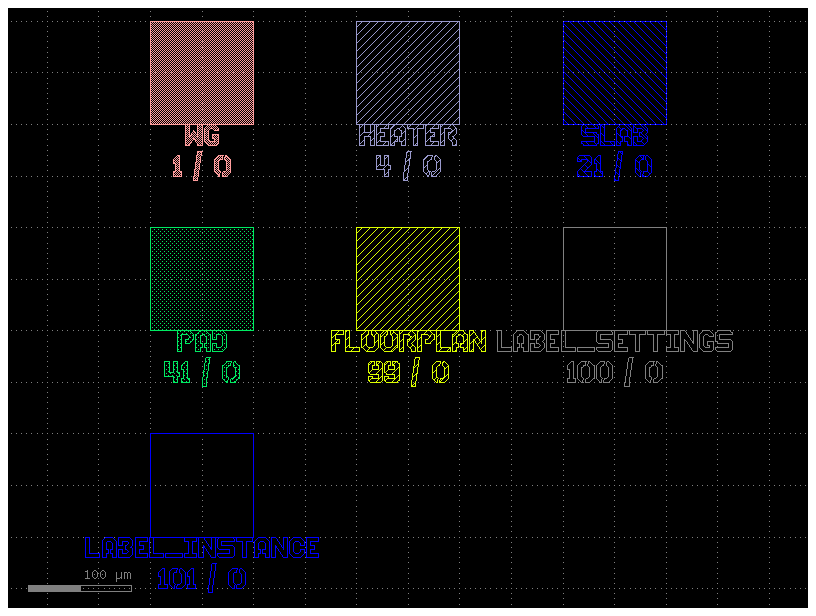

In [37]:
LAYER_VIEWS = PDK.layer_views
c = LAYER_VIEWS.preview_layerset()
c.show()
c.plot()


The new versions of GDS Factory allow to view the Layer Stack also (3D view of the fabrication flow). The following code allows to generate and view the Layer Stack of the generic PDK. Reference: https://www.degruyter.com/document/doi/10.1515/nanoph-2013-0034/html

The layers and the thicknesses have been defined previously on the PDK, so it is possible to view in 3D some of the components in the PDK. 

See the [Reference Manual](https://gdsfactory.github.io/gdsfactory/components.html) and read the list of the available components.

Here are some examples of the 3D views of this photonic components

2026-06-12 15:48:16.169 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


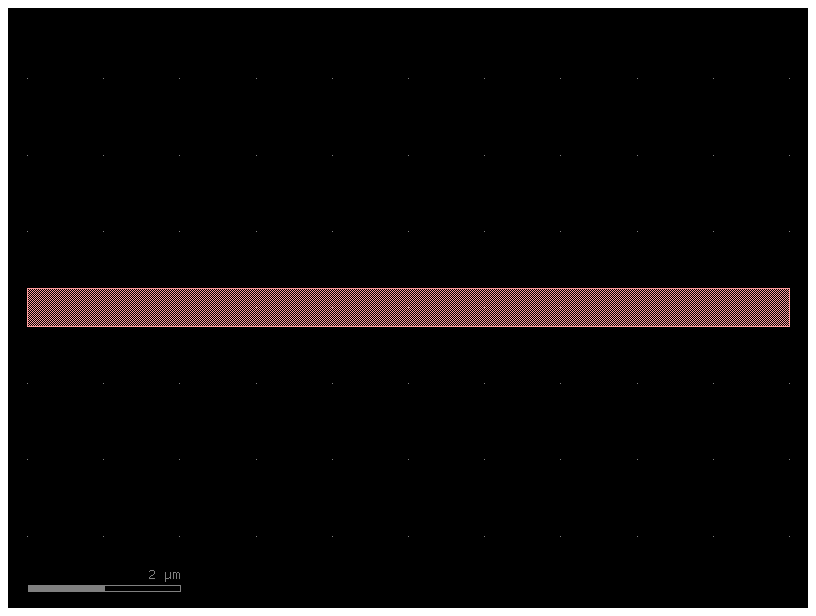

In [38]:
xs = gf.cross_section.strip(width=0.5, layer = 'WG')

c = gf.components.straight(length=10, cross_section=xs)  #Deep 
c.plot() # To view the component on Notebook
c.show() # To view on KLayout
scene = c.to_3d()
scene.show()


2026-06-12 15:48:21.646 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server
2026-06-12 15:48:21.722 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


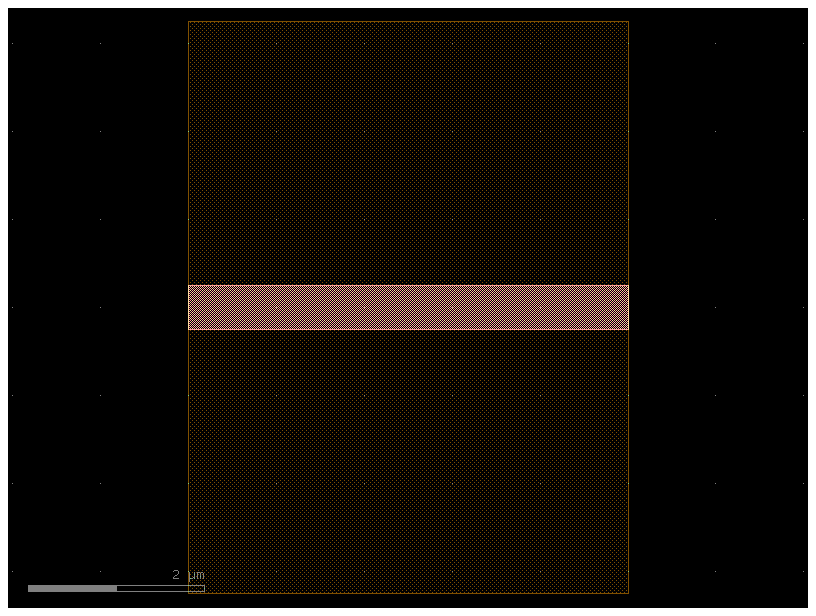

In [39]:
c = gf.components.straight(length=5, cross_section='rib') #Shallow
c.plot()
c.show()

scene = c.to_3d()
c.show()
scene.show()

In [40]:
c = cells.taper_strip_to_ridge(length=10) #Taper
c.show()

scene = c.to_3d()
scene.show()

2026-06-12 15:48:26.153 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


2026-06-12 15:48:29.083 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


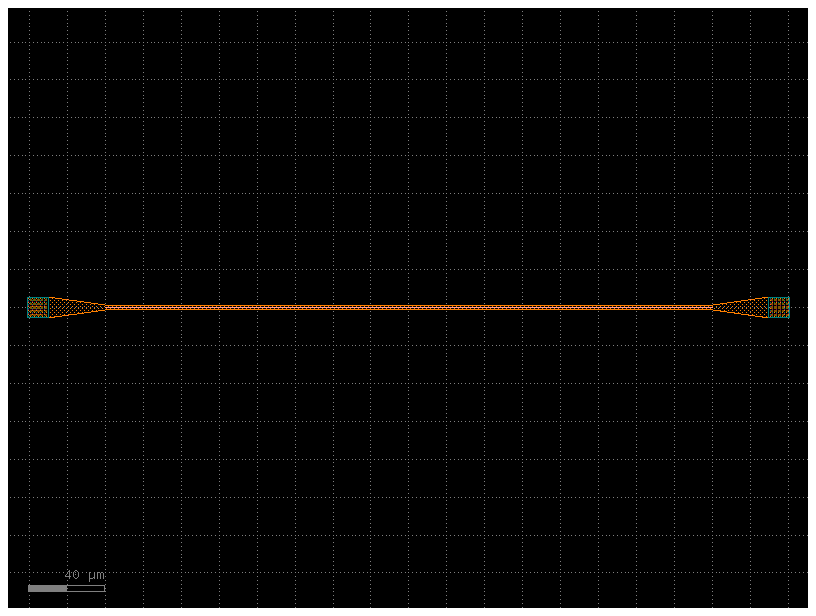

In [41]:
c = cells.straight_heater_metal()

#c.pprint_ports()

c.plot()
c.show()
#c.draw_ports()

scene = c.to_3d()
scene.show()

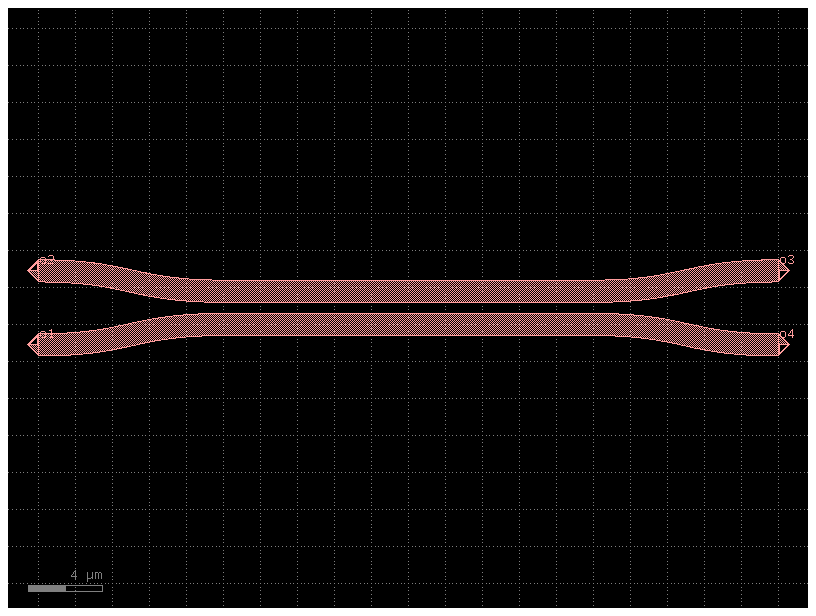

In [42]:
gf.gpdk.PDK.activate()
xs_io = gf.cross_section.strip(width=1.2, layer=(1, 0))

c = gf.components.coupler(gap=0.6, length=20, dy=4, dx=10, cross_section=xs_io, allow_min_radius_violation=False, bend='bend_s').copy()
c.draw_ports()
c.plot()

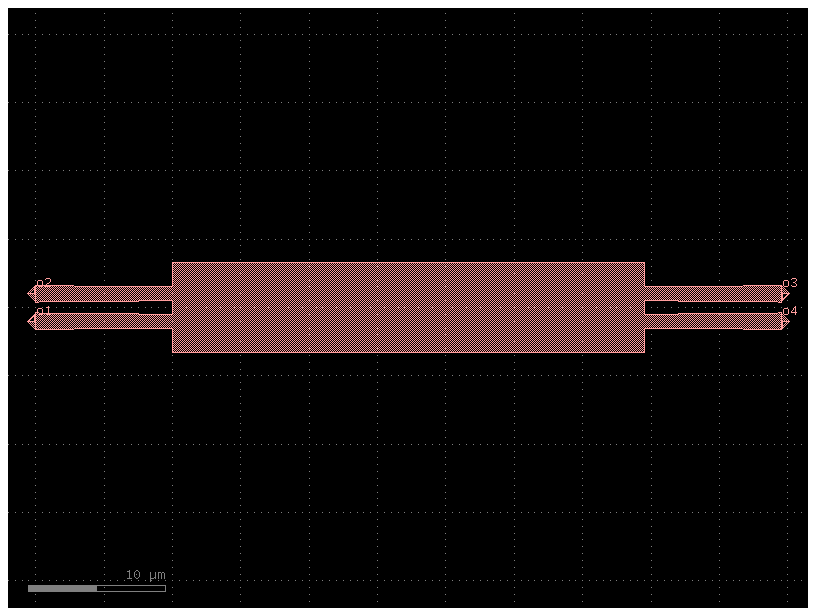

In [43]:
c = gf.components.mmi(inputs=2, outputs=2, width=1.2, width_taper=1, length_taper=10, length_mmi=34.518, width_mmi=6.6, gap_input_tapers=1, gap_output_tapers=1, taper='taper', straight='straight', cross_section='strip').copy()
c.draw_ports()
c.plot()

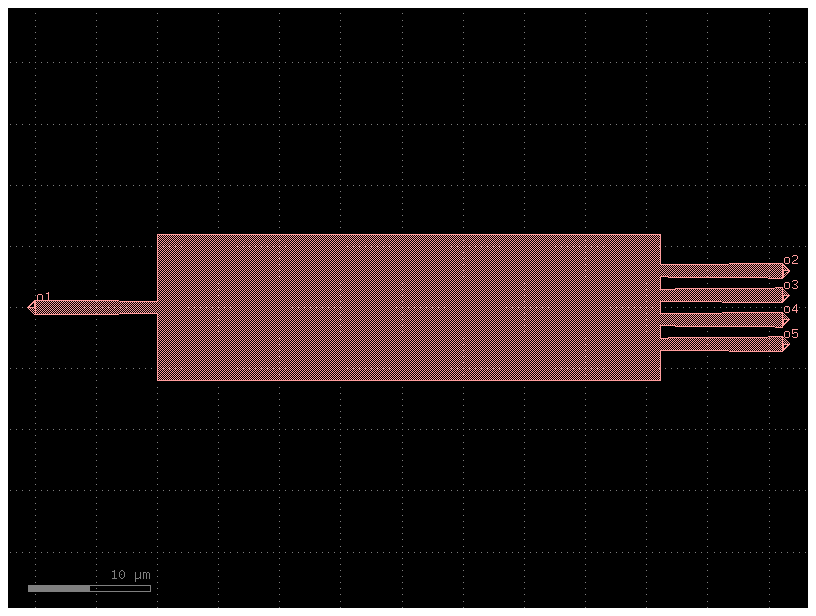

In [44]:
c = gf.components.mmi(inputs=1, outputs=4, width=1.2, width_taper=1, length_taper=10, length_mmi=41.0886, width_mmi=12, gap_input_tapers=1, gap_output_tapers=1, taper='taper', straight='straight', cross_section='strip').copy()
c.draw_ports()
c.plot()

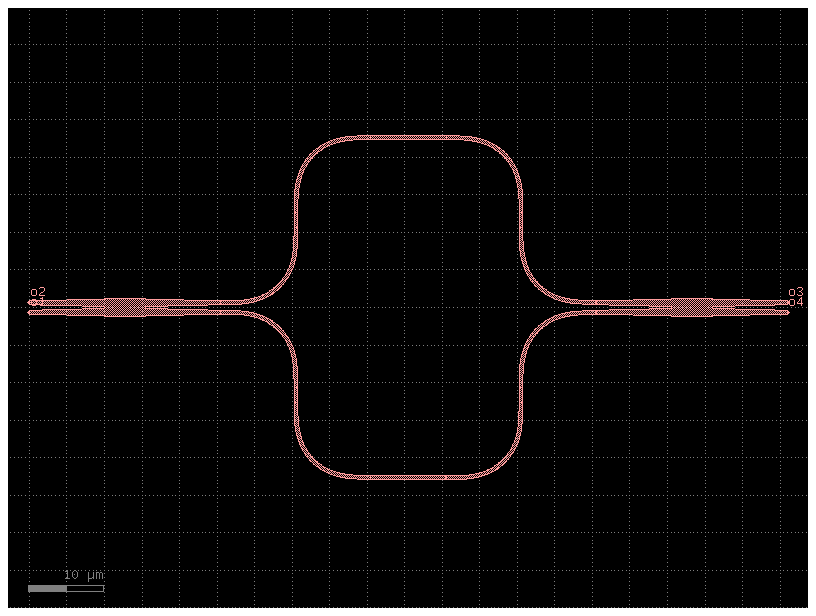

In [45]:




c = gf.components.mzi_lattice_mmi(coupler_widths=(None, None), coupler_widths_tapers=(1, 1), coupler_lengths_tapers=(10, 10), coupler_lengths_mmis=(5.5, 5.5), coupler_widths_mmis=(2.5, 2.5), coupler_gaps_mmis=(0.25, 0.25), taper_functions_mmis=('taper', 'taper'), straight_functions_mmis=('straight', 'straight'), cross_sections_mmis=('strip', 'strip'), delta_lengths=(0,), mzi='mzi2x2_2x2', splitter='mmi2x2').copy()
c.draw_ports()
c.plot()

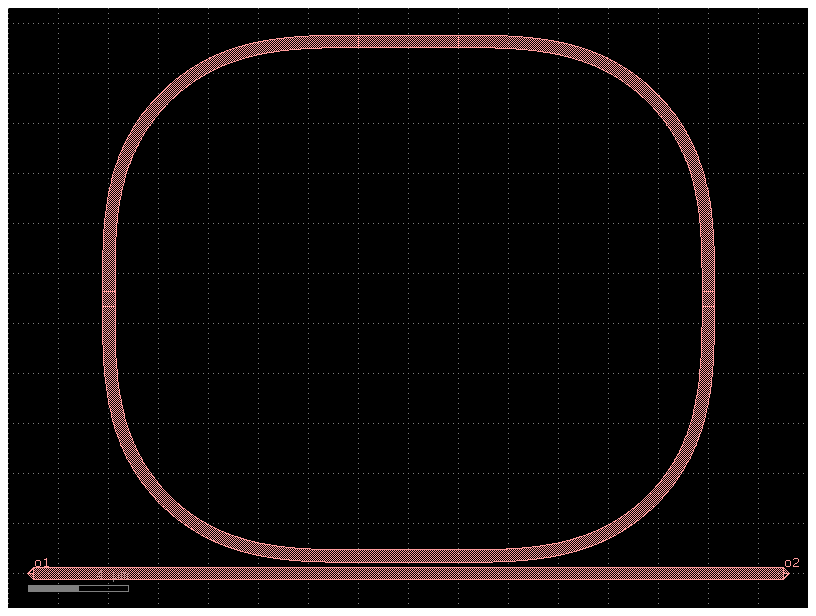

In [46]:

c = gf.components.ring_single(gap=0.2, length_x=4, length_y=0.6, bend='bend_euler', straight='straight', coupler_ring='coupler_ring', cross_section='strip').copy()
c.draw_ports()
c.plot()

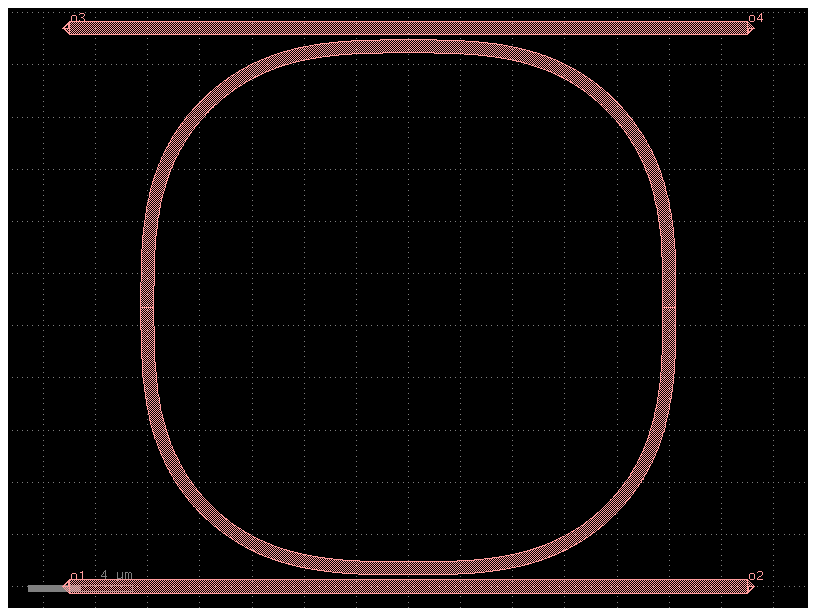

In [47]:

gf.gpdk.PDK.activate()

c = gf.components.ring_double(gap=0.2, length_x=0.01, length_y=0.01, bend='bend_euler', straight='straight', coupler_ring='coupler_ring', cross_section='strip').copy()
c.draw_ports()
c.plot()

- Use your design results from Lab2 and Lab3 to create **layout** instances of your designed components: DCs, MMIs, MZIs & Ring Resonators. 

## 2. Layout Fundamentals

A cell is a function that returns a Component. In GDS each component must have a unique name. Two components stored in the GDS file cannot have the same name. They need to be references (instances) of the same component.

![GDSFactoryComponents][def]


[def]: https://i.imgur.com/oeuKGsc.png

2026-06-12 15:48:59.148 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


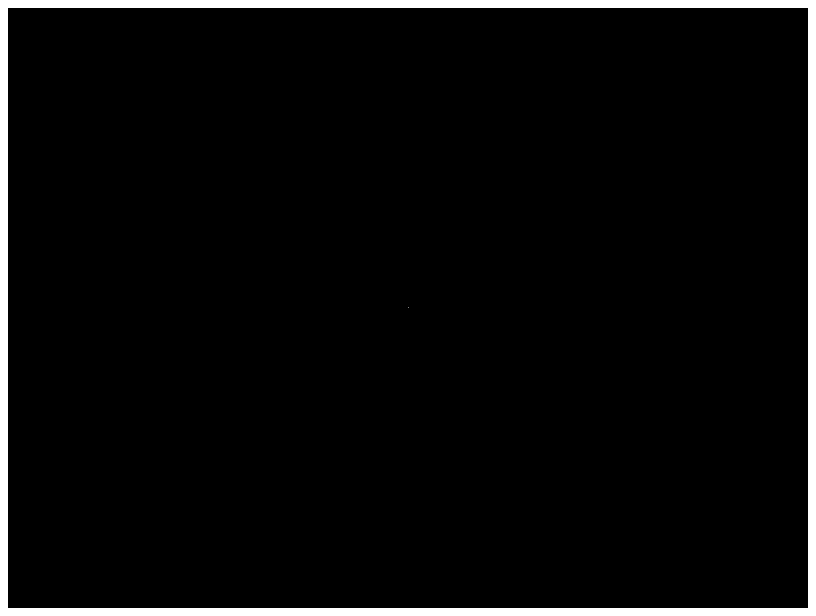

In [48]:
c = gf.Component()
c.plot()
c.show()

Let's build a Component from scratch. A die (chip) for a photonic layout. The PDK or Design Manual should specify the Layer for the bounding box (dicing line). 
We should also consider: 
1. The die dimensions and 
2. The border for dicing 

2026-06-12 15:49:02.053 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


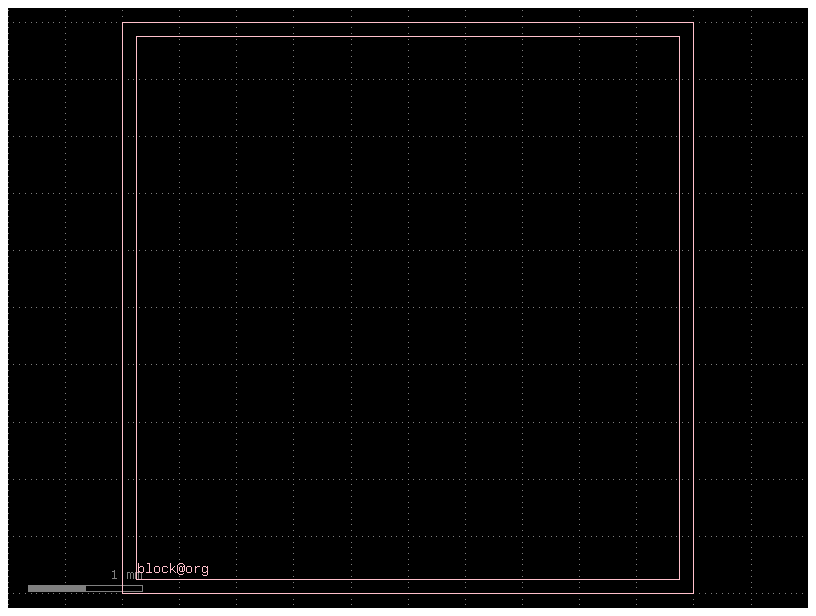

In [49]:
wgw = 0.5
dieL = 5000
dieW = 5000
border = 125
layer_wg = "WG"
layer_box = "FLOORPLAN"

# Die specifications (Chip)
box = gf.Component()

obox = box.add_ref(gf.components.rectangle(size=(dieW,dieL),layer=layer_box))
ibox = box.add_ref(gf.components.rectangle(size=(dieW-border*2,dieL-border*2),layer=layer_box)).dmovex(border).dmovey(border)
box = gf.boolean(A=obox, B=ibox, operation="A-B", layer="FLOORPLAN")

# Adding ports to a component 
box.add_port(name="block@org", center=[border,border], width=1, orientation=0, layer=layer_box)

box.draw_ports()
box.show()
box.plot()

### Mantra: 
Once that we have a working 'new' component, we shall convert it into a Cell. This will allow us to have a hierarchical design

2026-06-12 15:49:11.260 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


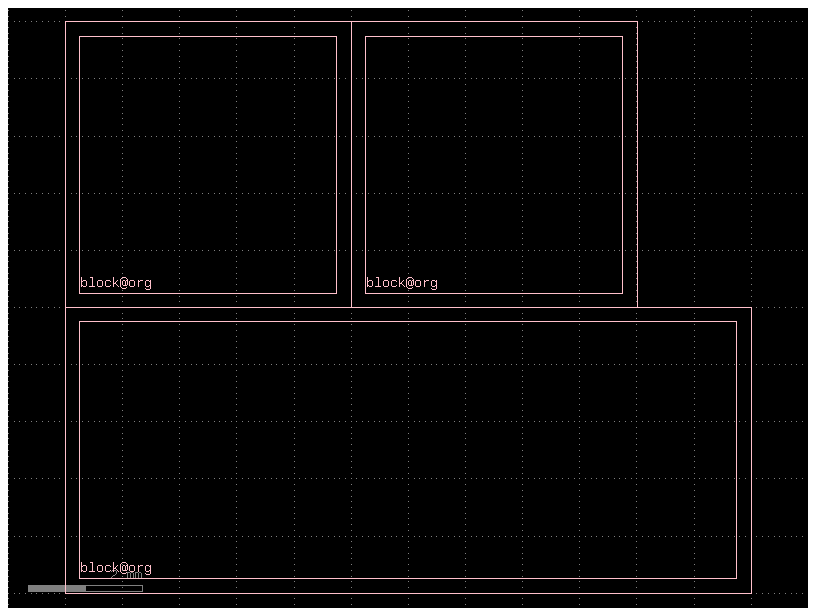

In [50]:
# 1. We define the cell as a function with it's corresponding parameters (and defaults)
gf.clear_cache()

@gf.cell
def die(dieL = 5000, dieW = 5000, border = 250, layer_box = "FLOORPLAN"):
    # Die specifications (Chip)
    box = gf.Component()
    obox = box.add_ref(gf.components.rectangle(size=(dieW,dieL),layer=layer_box))
    ibox = box.add_ref(gf.components.rectangle(size=(dieW-border*2,dieL-border*2),layer=layer_box)).dmovex(border).dmovey(border)
    box = gf.boolean(A=obox, B=ibox, operation="A-B", layer=layer_box)
    # Adding ports to a component 
    box.add_port(name="block@org", center=[border,border], width=1, orientation=0, layer=layer_box)
    box.draw_ports()
    return box

# 2. We instantiate references of each cell. We can also name it individually to avoid problems
wafer = gf.Component()
dieW1 = 5000
dieW2 = 10000

c1 = wafer.add_ref(die(dieW = dieW))
c2 = wafer.add_ref(die(dieW = dieW))
c3 = wafer.add_ref(die(dieW = 12000))

c2.dmovex(dieW1)
c3.dmovey(-5000)
wafer.show()
wafer.plot()


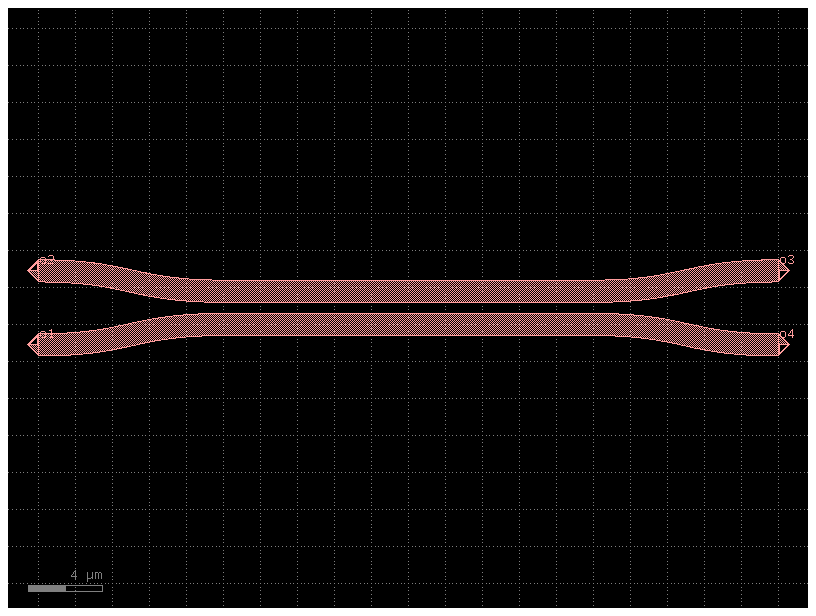

In [51]:
import gdsfactory as gf

@gf.cell
def coupler_celda() -> gf.Component:
    gf.gpdk.PDK.activate()
    xs_io = gf.cross_section.strip(width=1.2, layer=(1, 0))

    c = gf.components.coupler(
        gap=0.6, 
        length=20, 
        dy=4, 
        dx=10, 
        cross_section=xs_io, 
        allow_min_radius_violation=False, 
        bend='bend_s'
    ).copy()
    
    c.draw_ports()
    return c

coupler_final = coupler_celda()
coupler_final.plot()

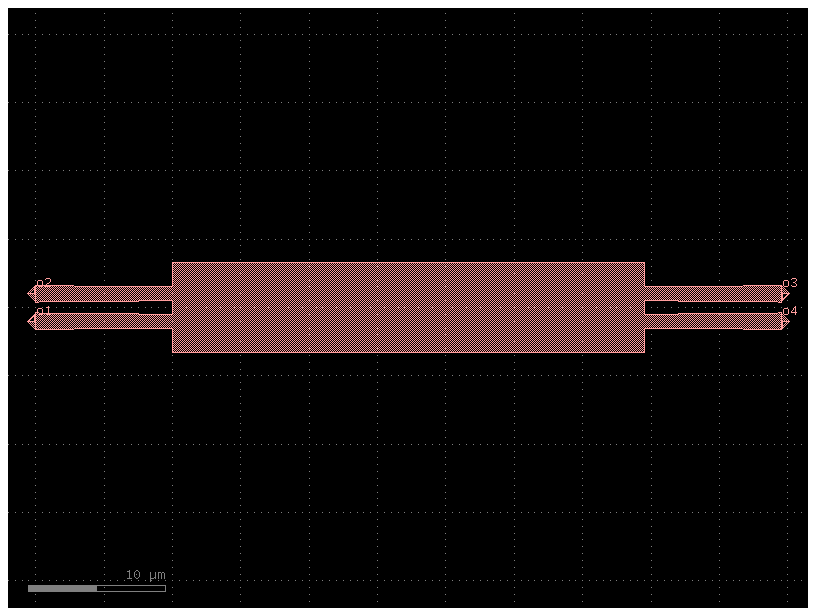

In [52]:
import gdsfactory as gf

@gf.cell
def mmi_2x2_celda() -> gf.Component:
    c = gf.components.mmi(
        inputs=2, 
        outputs=2, 
        width=1.2, 
        width_taper=1, 
        length_taper=10, 
        length_mmi=34.518, 
        width_mmi=6.6, 
        gap_input_tapers=1, 
        gap_output_tapers=1, 
        taper='taper', 
        straight='straight', 
        cross_section='strip'
    ).copy()
    
    c.draw_ports()
    return c

mmi_final = mmi_2x2_celda()
mmi_final.plot()

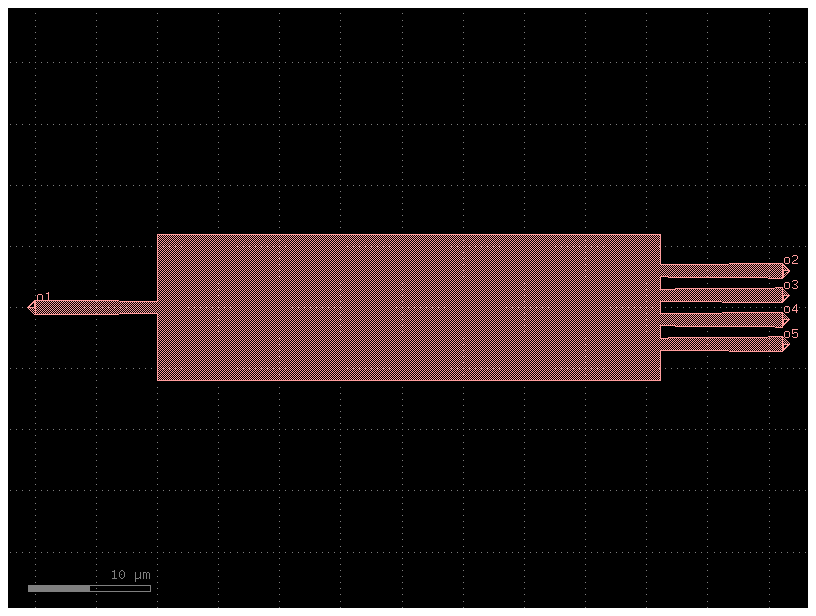

In [53]:
import gdsfactory as gf

@gf.cell
def mmi_1x4_celda() -> gf.Component:
    c = gf.components.mmi(
        inputs=1, 
        outputs=4, 
        width=1.2, 
        width_taper=1, 
        length_taper=10, 
        length_mmi=41.0886, 
        width_mmi=12, 
        gap_input_tapers=1, 
        gap_output_tapers=1, 
        taper='taper', 
        straight='straight', 
        cross_section='strip'
    ).copy()
    
    c.draw_ports()
    return c

mmi_1x4_final = mmi_1x4_celda()
mmi_1x4_final.plot()

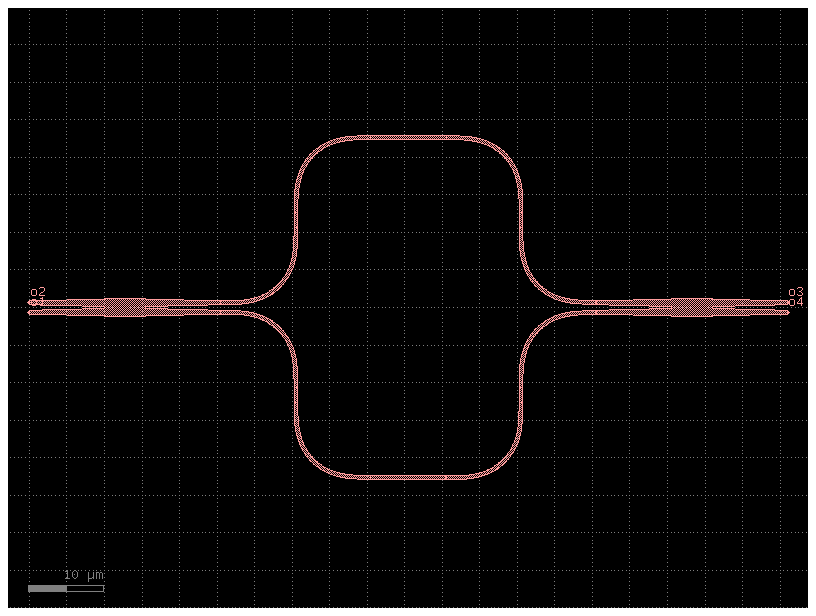

In [54]:
import gdsfactory as gf

@gf.cell
def mzi_lattice_celda() -> gf.Component:
    gf.gpdk.PDK.activate()

    c = gf.components.mzi_lattice_mmi(
        coupler_widths=(None, None), 
        coupler_widths_tapers=(1, 1), 
        coupler_lengths_tapers=(10, 10), 
        coupler_lengths_mmis=(5.5, 5.5), 
        coupler_widths_mmis=(2.5, 2.5), 
        coupler_gaps_mmis=(0.25, 0.25), 
        taper_functions_mmis=('taper', 'taper'), 
        straight_functions_mmis=('straight', 'straight'), 
        cross_sections_mmis=('strip', 'strip'), 
        delta_lengths=(0,), 
        mzi='mzi2x2_2x2', 
        splitter='mmi2x2'
    ).copy()
    
    c.draw_ports()
    return c

mzi_lattice_final = mzi_lattice_celda()
mzi_lattice_final.plot()

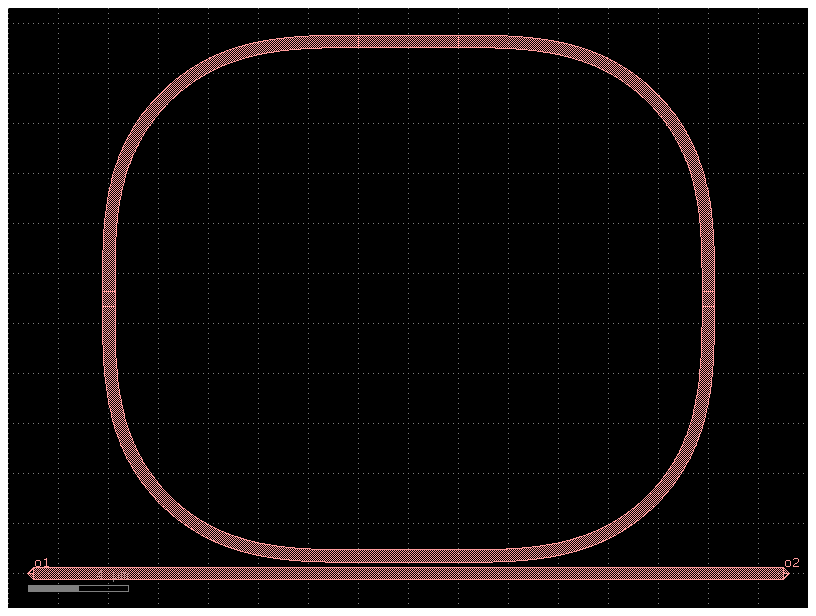

In [55]:
import gdsfactory as gf

@gf.cell
def ring_single_celda() -> gf.Component:
    gf.gpdk.PDK.activate()

    c = gf.components.ring_single(
        gap=0.2, 
        length_x=4, 
        length_y=0.6, 
        bend='bend_euler', 
        straight='straight', 
        coupler_ring='coupler_ring', 
        cross_section='strip'
    ).copy()
    
    c.draw_ports()
    return c

ring_final = ring_single_celda()
ring_final.plot()

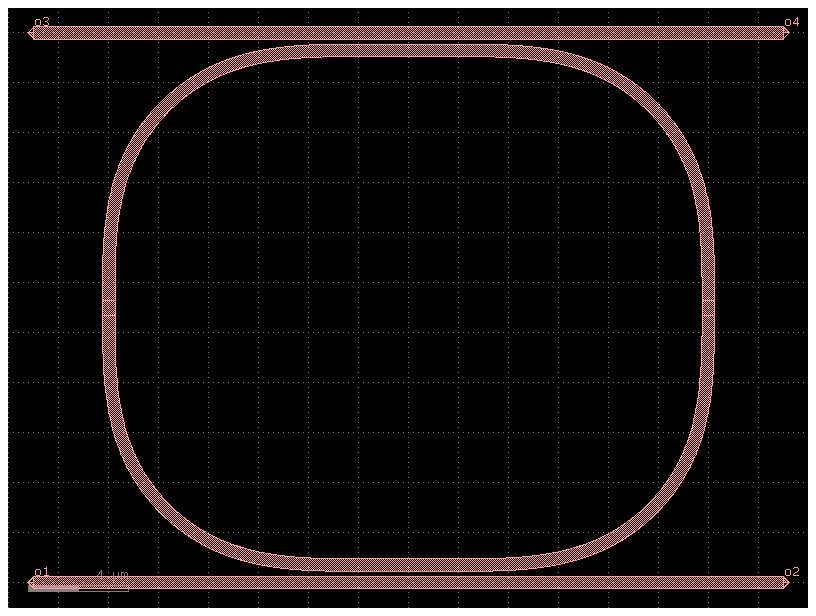

In [56]:
import gdsfactory as gf

@gf.cell
def ring_double_celda() -> gf.Component:
    gf.gpdk.PDK.activate()

    c = gf.components.ring_double(
        gap=0.2, 
        length_x=4, 
        length_y=0.6, 
        bend='bend_euler', 
        straight='straight', 
        coupler_ring='coupler_ring', 
        cross_section='strip'
    ).copy()
    
    c.draw_ports()
    return c

ring_double_final = ring_double_celda()
ring_double_final.plot()

## 3. Complete Layout

2026-06-12 15:49:38.261 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


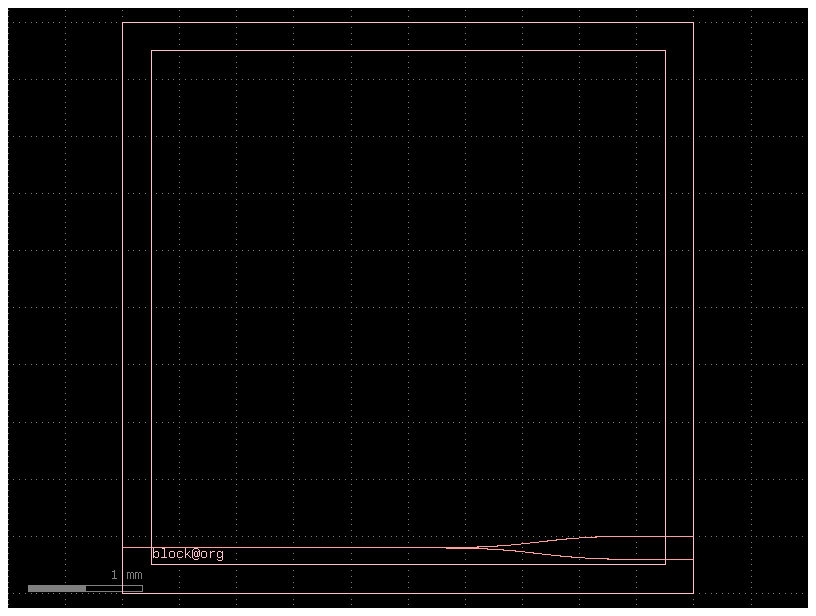

In [57]:
layer_wg  = "WG"
minrad = 50
dieW = 5000

main = gf.Component()

die_ref = main.add_ref(die(dieW = dieW, layer_box="FLOORPLAN"))

## Add first a test MMI routed from side to side
c_mmi = cells.mmi1x2()
mmi = main.add_ref(c_mmi)
mmi.dmovex(die_ref["block@org"].dx + 0.5*dieW).dmovey(die_ref['block@org'].dy + 150)

## Route waveguides from MMI to the die edges
xs = 'strip'
### First add the i/o waveguides - to be sure you 'cut' on a straight section
strin = (main.add_ref(gf.components.straight(length=500, cross_section='strip')).dmovex(0).dmovey(mmi['o1'].dy))
strout1 = (main.add_ref(gf.components.straight(length=500, cross_section=xs)).drotate(180).dmovey(mmi.ports['o3'].dy-100).dmovex(dieW))
strout2 = (main.add_ref(gf.components.straight(length=500, cross_section=xs)).drotate(180).dmovey(mmi.ports['o2'].dy+100).dmovex(dieW))
### Then route from the i/o waveguides to the MMI
gf.routing.route_single_sbend(main,port1=strin['o2'], port2=mmi['o1'], cross_section=xs)
gf.routing.route_single_sbend(main,port1=mmi['o2'], port2=strout2['o2'], cross_section=xs)
gf.routing.route_single_sbend(main,port1=mmi['o3'], port2=strout1['o2'], cross_section=xs)

main.plot()
main.show()

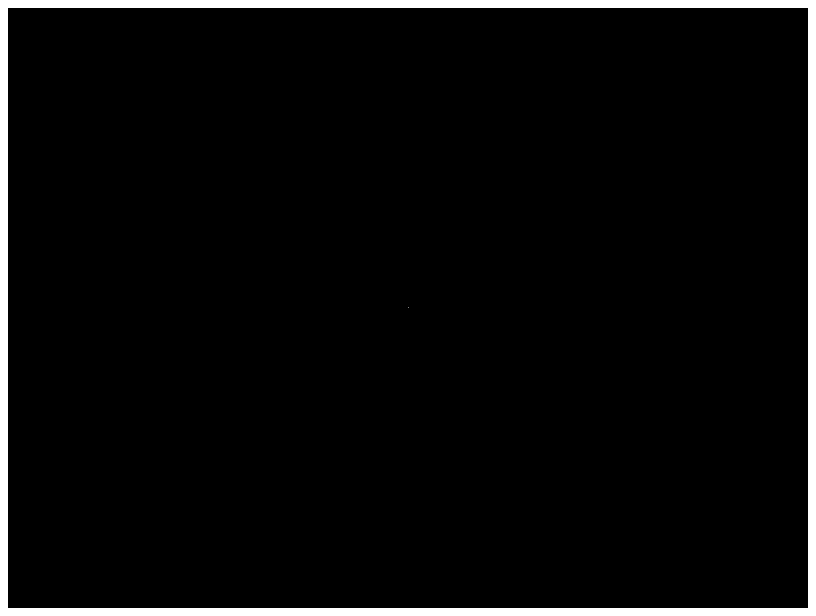

In [58]:
# Let's create a MMI tree

c = gf.Component()
c_mmi = cells.mmi1x2()
...
c.plot()

In [59]:
# Once we "test" the high-level component, we can create a cell for it
@gf.cell 
def mmi_tree_1x4(pad_x = 250 ,pad_y = 250):
    c = gf.Component()
    c_mmi = cells.mmi1x2()
    mmi1 = c.add_ref(c_mmi)
    mmi2 = c.add_ref(c_mmi)
    mmi3 = c.add_ref(c_mmi)

    mmi2.dmovex(pad_x).dmovey(pad_y)
    mmi3.dmovex(pad_x).dmovey(-pad_y)

    gf.routing.route_single_sbend(component=c, port1= mmi1['o2'], port2=mmi2['o1'],cross_section='strip')
    gf.routing.route_single_sbend(component=c, port1= mmi1['o3'], port2=mmi3['o1'],cross_section='strip')
    c.add_port(name='o1', port=mmi1['o1'])
    c.add_port(name='o2', port=mmi2['o2'])
    c.add_port(name='o3', port=mmi2['o3'])
    c.add_port(name='o4', port=mmi3['o2'])
    c.add_port(name='o5', port=mmi3['o3'])
    c.draw_ports()
    return c

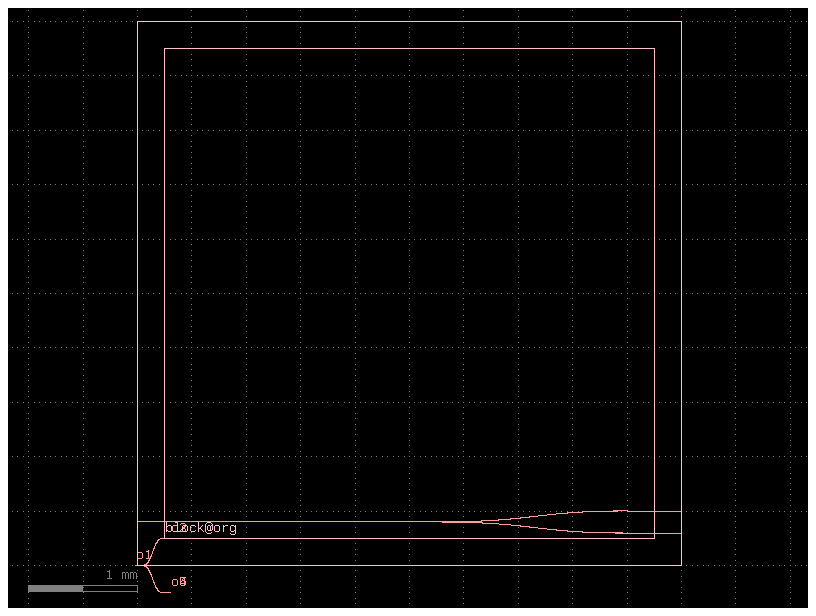

In [60]:
# With the cell created, we can instantiate and use it in our main component

cell_1x4 = main.add_ref(mmi_tree_1x4())
main.plot()


2026-06-12 15:49:51.457 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


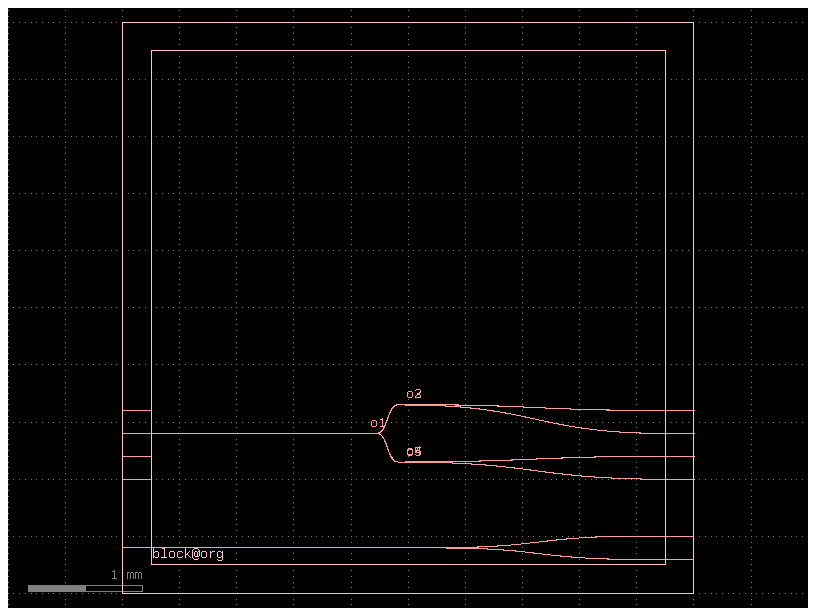

In [61]:
## Arrayed waveguides and MMI tree

sp = 200
border = 250

in_arr = main.add_ref(
    gf.components.straight_array(n=4, spacing=sp, length=border, cross_section=xs)
).dmovey(
    1000
)  #!!!!!! Easy to put IO Waveguides for a complete design !!!!

out_arr = (
    main.add_ref(
        gf.components.straight_array(n=4, spacing=sp, length=border, cross_section=xs)
    )
    .dmovex(dieW - border)
    .dmovey(1000)
)

cell_1x4.dmovex(0.5*dieW - mmi_tree_1x4().dxsize).dmovey(in_arr['o6'].dy)
gf.routing.route_single_sbend(component=main, port1=in_arr['o6'], port2=cell_1x4['o1'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o2'], port2=out_arr['o4'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o3'], port2=out_arr['o3'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o4'], port2=out_arr['o2'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o5'], port2=out_arr['o1'])
main.plot()
main.show()

### Mantra:
It's useful to use memorize this mantra: 
- Add_references 
- Connect_them
- Move_them

### Other Routing options examples:

Please check the GDSFactory Routing API for more information about advanced routing functionalities

[Routing API](https://gdsfactory.github.io/gdsfactory/api_routing.html) 

## 4. Exercises. 

Part a) Creating components
- Create a cell component for a unbalanced MZI, using 2x2 50:50 MMIs with arm length difference as parameter
- Create a cell component based on the previous, where the arms have thermal tuners on top of each one
- Create a cell component for an all-pass ring resonator, using 2x2 50:50 MMIs, with extra length parameter for different perimeters
- Create a cell component based on the previous, where the ring has a thermal tuner on top along all the perimeter
- Create a cell component based on existing GDSfactory spiral components, with length as parameter

Part b) Creating die
- Create a die  W = 5 mm x L = 10 mm 
- Create an array of I/Os spaced at 250 µm (as much I/Os as the width allows)
- Create a cell component of this die, with I/Os accessible to connect

Part c) Floorplaning and die layout
- Make an instance of the die as host component for your layout
- Add 3 sets of 3 straight waveguides, from left to right of the die, top, middle and bottom of the die
- Add 2 of each of the components above, with different lengths
- Connect all your components to the I/Os 

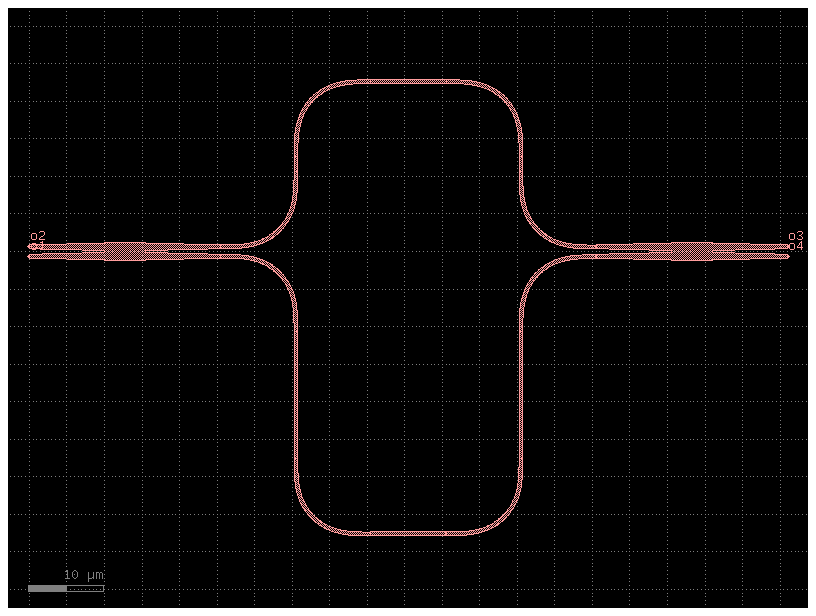

In [62]:
import gdsfactory as gf

@gf.cell
def mzi_unbalanced_celda(delta_length: float = 10.0) -> gf.Component:
    gf.gpdk.PDK.activate()

    # Ahora 'delta_length' es un parámetro ajustable de la celda
    c = gf.components.mzi_lattice_mmi(
        coupler_widths=(None, None), 
        coupler_widths_tapers=(1, 1), 
        coupler_lengths_tapers=(10, 10), 
        coupler_lengths_mmis=(5.5, 5.5), 
        coupler_widths_mmis=(2.5, 2.5), 
        coupler_gaps_mmis=(0.25, 0.25), 
        taper_functions_mmis=('taper', 'taper'), 
        straight_functions_mmis=('straight', 'straight'), 
        cross_sections_mmis=('strip', 'strip'), 
        delta_lengths=(delta_length,), # Aquí usamos el parámetro
        mzi='mzi2x2_2x2', 
        splitter='mmi2x2'
    ).copy()
    
    c.draw_ports()
    return c

mzi_final = mzi_unbalanced_celda(delta_length=30.0)
mzi_final.plot()

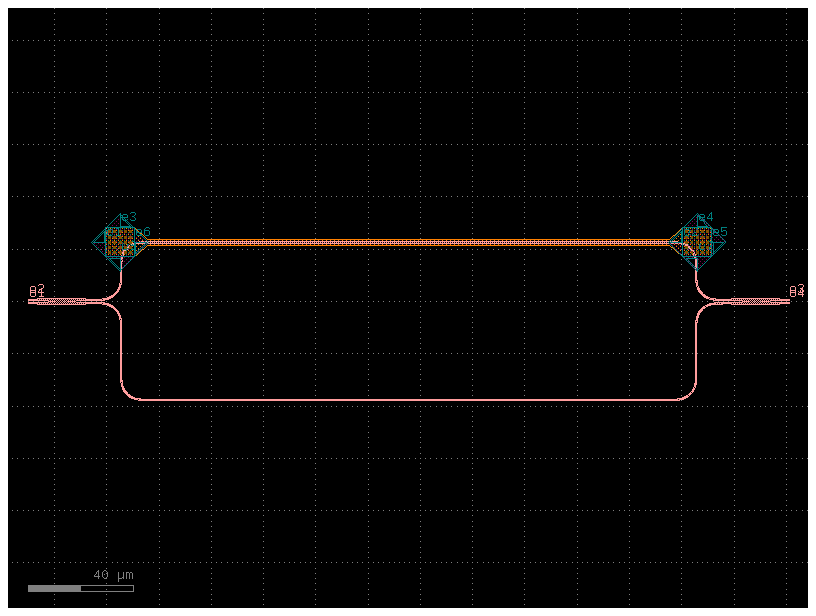

In [63]:
import gdsfactory as gf
@gf.cell
def mzi_phase_shifter_celda(delta_length: float = 10.0) -> gf.Component:
    gf.gpdk.PDK.activate()
    c = gf.components.mzi2x2_2x2_phase_shifter(
        delta_length=delta_length, # Parámetro variable
        length_y=2, 
        length_x=200, 
        bend='bend_euler', 
        straight='straight', 
        straight_x_top='straight_heater_metal', 
        splitter='mmi2x2', 
        combiner='mmi2x2', 
        with_splitter=True, 
        port_e1_splitter='o3', 
        port_e0_splitter='o4', 
        port_e1_combiner='o3', 
        port_e0_combiner='o4', 
        port1='o1', 
        port2='o2', 
        nbends=2, 
        cross_section='strip', 
        mirror_bot=False, 
        add_optical_ports_arms=False, 
        min_length=0.01, 
        auto_rename_ports=True, 
        auto_detect_port_names=False
    ).copy()
    c.draw_ports()
    return c
mzi_final = mzi_phase_shifter_celda(delta_length=30.0)
mzi_final.plot()

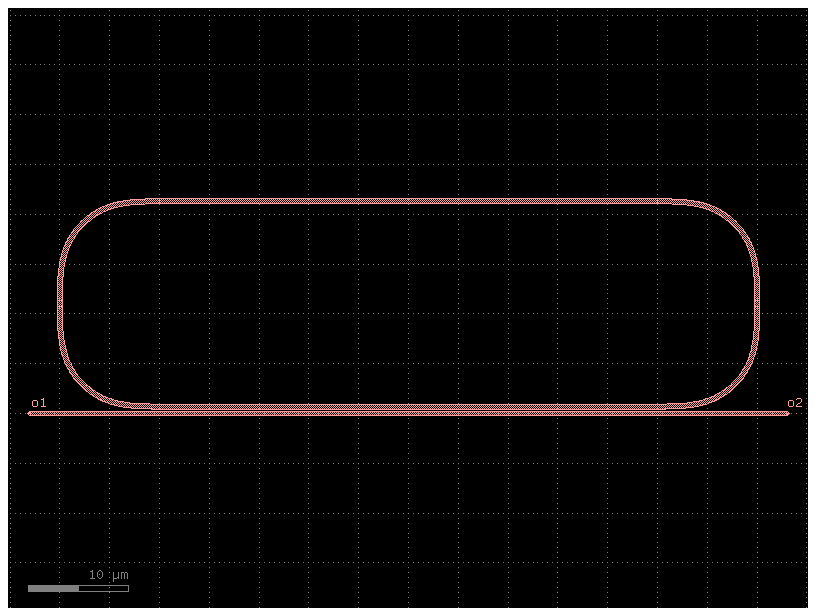

In [64]:
import gdsfactory as gf

@gf.cell
def ring_all_pass_celda(length_x: float = 4.0) -> gf.Component:
    gf.gpdk.PDK.activate()

    # Usamos ring_single como base para el all-pass resonator
    c = gf.components.ring_single(
        gap=0.2, 
        length_x=length_x,    # Parámetro para ajustar el perímetro
        length_y=0.6, 
        bend='bend_euler', 
        straight='straight', 
        coupler_ring='coupler_ring', # MMI 2x2 como acoplador 50:50
        cross_section='strip'
    ).copy()
    
    c.draw_ports()
    return c

ring_final = ring_all_pass_celda(length_x=50.0)
ring_final.plot()

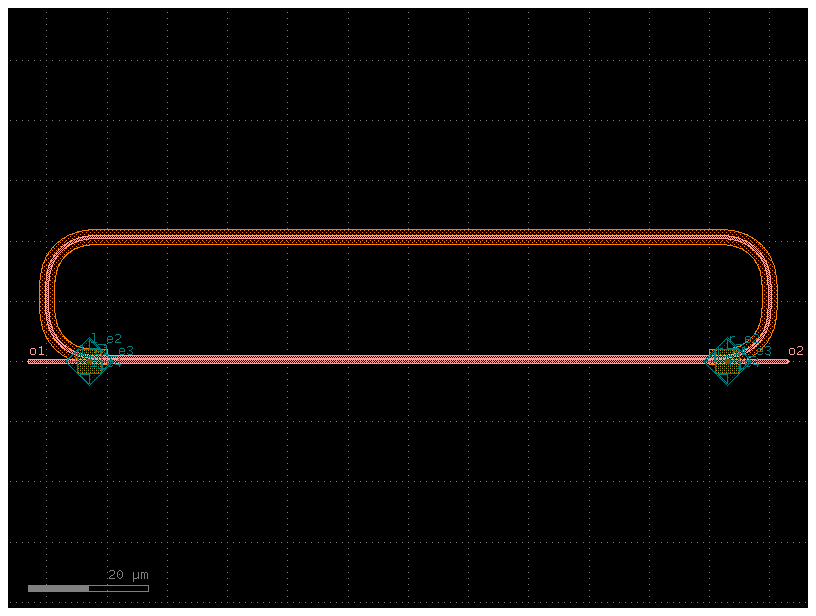

In [65]:
import gdsfactory as gf

@gf.cell
def ring_all_pass_heater_celda(length_x: float = 4.0) -> gf.Component:
    gf.gpdk.PDK.activate()

    # Usamos la función de heater predefinida
    c = gf.components.ring_single_heater(
        gap=0.2, 
        length_x=length_x, # Variable por parámetro
        length_y=0.01, 
        coupler_ring='coupler_ring', 
        straight='straight', 
        bend='bend_euler', 
        cross_section_heater='heater_metal', 
        cross_section_waveguide_heater='strip_heater_metal', 
        cross_section='strip', 
        via_stack='via_stack_heater_mtop_mini', 
        via_stack_offset=(1, 0), 
        with_drop=False
    ).copy()
    
    c.draw_ports()
    return c

ring_heater_final = ring_all_pass_heater_celda(length_x=100.0)
ring_heater_final.plot()

/home/gabri/cifoin-lab4/.venv/lib/python3.12/site-packages/gdsfactory/components/bends/bend_circular.py:86: UserWarning: {'width': 0.5} ignored for cross_section 'strip'
  x = gf.get_cross_section(cross_section, width=width or x.width)


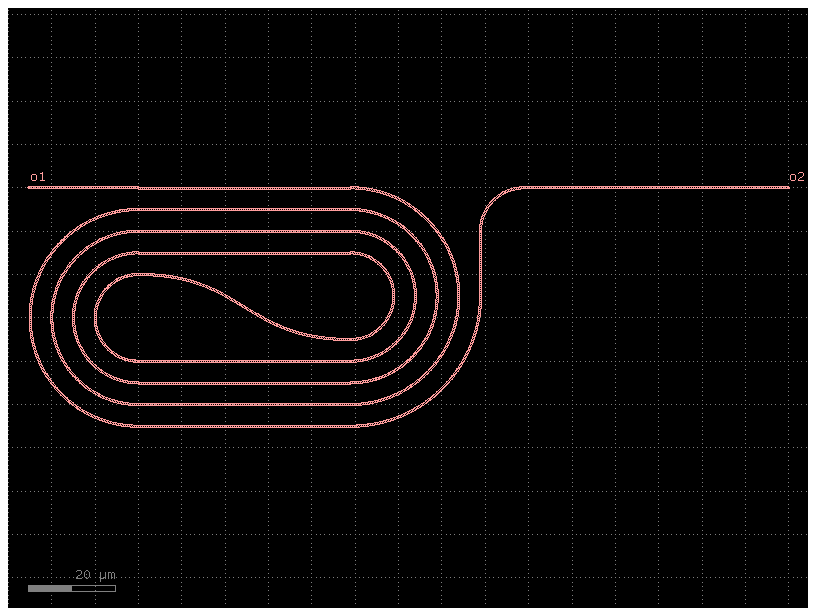

In [66]:
import gdsfactory as gf

@gf.cell
def spiral_parametrizada(length: float = 1000.0) -> gf.Component:
    gf.gpdk.PDK.activate()

    # Creamos la espiral usando el parámetro 'length'
    c = gf.components.spiral_racetrack_fixed_length(
        length=length, 
        in_out_port_spacing=150, 
        n_straight_sections=8, 
        min_spacing=5, 
        bend='bend_circular', 
        bend_s='bend_s', 
        cross_section='strip'
    ).copy()
    
    c.draw_ports()
    return c

espiral_final = spiral_parametrizada(length=1000.0)
espiral_final.plot()

2026-06-12 15:50:21.663 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


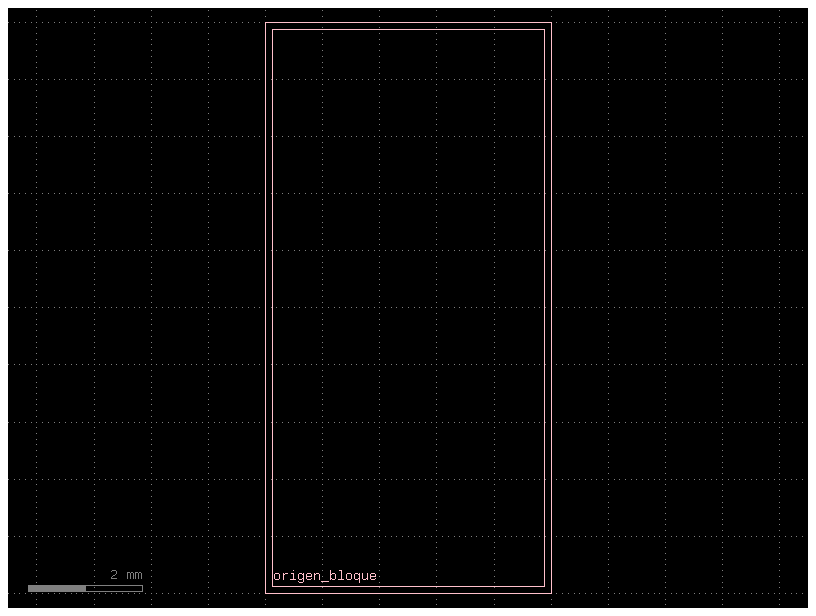

In [67]:
import gdsfactory as gf

gf.clear_cache()

@gf.cell
def troquel_con_marco(ancho: float = 5000.0, alto: float = 10000.0, margen: float = 125.0) -> gf.Component:
    # Creamos un componente base con nombre identificativo
    c = gf.Component("die_marco_hueco")
    capa_plano = "FLOORPLAN"
    
    # Cajas exterior e interior para la sustracción booleana
    caja_ext = c.add_ref(gf.components.rectangle(size=(ancho, alto), layer=capa_plano))
    
    caja_int = c.add_ref(gf.components.rectangle(
        size=(ancho - margen * 2, alto - margen * 2), 
        layer=capa_plano
    ))
    caja_int.dmovex(margen).dmovey(margen)
    
    # Operación A-B para vaciar el centro del troquel
    marco_die = gf.boolean(A=caja_ext, B=caja_int, operation="A-B", layer=capa_plano)
    
    # Añadimos el puerto de referencia
    marco_die.add_port(name="origen_bloque", center=[margen, margen], width=1, orientation=0, layer=capa_plano)
    marco_die.draw_ports()
    
    return marco_die

# Ejemplo de instanciación
wafer = gf.Component("oblea_ensamblaje")
die_ref = wafer.add_ref(troquel_con_marco(ancho=5000.0, alto=10000.0, margen=125.0))

wafer.plot()
wafer.show()

/home/gabri/cifoin-lab4/.venv/lib/python3.12/site-packages/gdsfactory/components/bends/bend_euler.py:110: UserWarning: {'width': 1.2} ignored for cross_section 'xs_f6a7b0ea'
  x = gf.get_cross_section(cross_section, width=width or x.width)


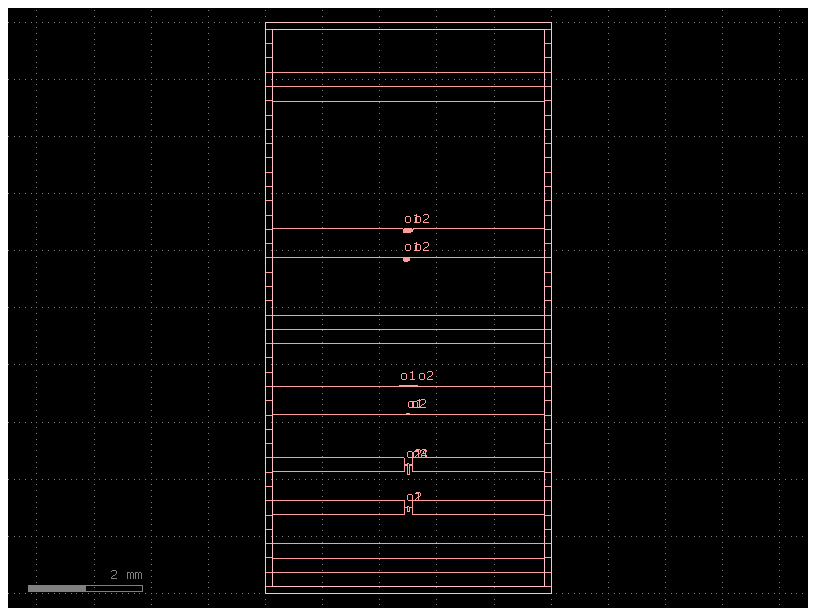

In [68]:
import gdsfactory as gf

# =================================================================
# PARTE B: CREACIÓN DEL TROQUEL (DIE) CON PUERTOS ÓPTICOS
# =================================================================
gf.clear_cache()

ancho_guia = 1.2
seccion_io = gf.cross_section.strip(width=ancho_guia, layer="WG", radius_min=10.0)

@gf.cell
def generar_troquel_optico(largo=10000, ancho=5000, margen=125, pitch=250):
    c = gf.Component("Troquel_Base")
    capa = "FLOORPLAN"

    # Marco hueco usando resta booleana
    caja_ext = c.add_ref(gf.components.rectangle(size=(ancho, largo), layer=capa))
    caja_int = c.add_ref(gf.components.rectangle(size=(ancho - 2*margen, largo - 2*margen), layer=capa)).dmovex(margen).dmovey(margen)
    marco = gf.boolean(A=caja_ext, B=caja_int, operation="A-B", layer=capa)
    c.add_ref(marco)

    # Generación de los arrays de E/S ópticas
    num_puertos = int((largo - 2*margen) // pitch) + 1  
    bloque_io = gf.components.straight_array(n=num_puertos, spacing=pitch - ancho_guia, length=margen, cross_section=seccion_io)
    
    entradas = c.add_ref(bloque_io).dmovey(margen)                                    
    salidas = c.add_ref(bloque_io).dmovex(ancho - margen).dmovey(margen)  

    # Clasificación y renombramiento de puertos a IN_x y OUT_x
    p_in = sorted([p for p in entradas.ports if p.orientation == 0], key=lambda p: p.center[1])
    p_out = sorted([p for p in salidas.ports if p.orientation == 180], key=lambda p: p.center[1])
    
    for i, p in enumerate(p_in, start=1):
        c.add_port(f"IN_{i}", port=p)
    for i, p in enumerate(p_out, start=1):
        c.add_port(f"OUT_{i}", port=p)
        
    return c

# =================================================================
# PARTE C: ENSAMBLAJE FINAL Y ENRUTAMIENTO
# =================================================================

@gf.cell
def ensamblar_chip_completo():
    chip = gf.Component("Diseno_Final_Laboratorio")
    
    # 1. Instanciamos el dado
    L_CHIP = 10000 
    W_CHIP = 5000  
    die = chip << generar_troquel_optico(largo=L_CHIP, ancho=W_CHIP, margen=125, pitch=250)

    # 2. Guías rectas de calibración
    puertos_calibracion = [2, 3, 4, 18, 19, 20, 35, 36, 37]
    longitud_guia = W_CHIP - (125 * 2) 

    for p in puertos_calibracion:
        guia_recta = chip << gf.components.straight(length=longitud_guia, cross_section=seccion_io)
        guia_recta.connect("o1", die.ports[f'IN_{p}'], allow_width_mismatch=True)

    # =================================================================
    # 3. Instanciación de componentes (NOMBRES ADAPTADOS)
    # =================================================================
    mzi_a = chip << mzi_unbalanced_celda(delta_length=100.0)
    mzi_b = chip << mzi_unbalanced_celda(delta_length=300.0)
    
    anillo_a = chip << ring_all_pass_celda(length_x=40.0)
    anillo_b = chip << ring_all_pass_celda(length_x=300.0)
    
    espiral_a = chip << spiral_parametrizada(length=1000.0)
    espiral_b = chip << spiral_parametrizada(length=1400.0)

    # =================================================================
    # 4. Alineación Matemática
    # =================================================================
    centro_x = W_CHIP / 2
    for componente in [mzi_a, mzi_b, anillo_a, anillo_b, espiral_a, espiral_b]:
        componente.dmovex(centro_x - componente.dcenter[0])

    anillo_a.dmovey(die.ports['IN_13'].dcenter[1] - anillo_a.ports['o1'].dcenter[1])
    anillo_b.dmovey(die.ports['IN_15'].dcenter[1] - anillo_b.ports['o1'].dcenter[1])
    
    espiral_a.dmovey(die.ports['IN_24'].dcenter[1] - espiral_a.ports['o1'].dcenter[1])
    espiral_b.dmovey(die.ports['IN_26'].dcenter[1] - espiral_b.ports['o1'].dcenter[1])

    mzi_a.dmovey(((die.ports['IN_6'].dcenter[1] + die.ports['IN_7'].dcenter[1]) / 2) - ((mzi_a.ports['o1'].dcenter[1] + mzi_a.ports['o2'].dcenter[1]) / 2))
    mzi_b.dmovey(((die.ports['IN_9'].dcenter[1] + die.ports['IN_10'].dcenter[1]) / 2) - ((mzi_b.ports['o1'].dcenter[1] + mzi_b.ports['o2'].dcenter[1]) / 2))

    # =================================================================
    # 5. Enrutamiento Óptico
    # =================================================================
    rutas_a_crear = [
        (mzi_a.ports['o1'], die.ports['IN_6']), (mzi_a.ports['o2'], die.ports['IN_7']),
        (mzi_a.ports['o4'], die.ports['OUT_6']), (mzi_a.ports['o3'], die.ports['OUT_7']),
        
        (mzi_b.ports['o1'], die.ports['IN_9']), (mzi_b.ports['o2'], die.ports['IN_10']),
        (mzi_b.ports['o4'], die.ports['OUT_9']), (mzi_b.ports['o3'], die.ports['OUT_10']),
        
        (anillo_a.ports['o1'], die.ports['IN_13']), (anillo_a.ports['o2'], die.ports['OUT_13']),
        (anillo_b.ports['o1'], die.ports['IN_15']), (anillo_b.ports['o2'], die.ports['OUT_15']),
        
        (espiral_a.ports['o1'], die.ports['IN_24']), (espiral_a.ports['o2'], die.ports['OUT_24']),
        (espiral_b.ports['o1'], die.ports['IN_26']), (espiral_b.ports['o2'], die.ports['OUT_26'])
    ]

    for p1, p2 in rutas_a_crear:
        gf.routing.route_single(chip, port1=p1, port2=p2, cross_section=seccion_io, allow_width_mismatch=True)

    return chip

chip_final = ensamblar_chip_completo()
chip_final.plot()